#PREDICTING THE GDP OF THE FOLLOWING QUARTER


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# OBJECTIVES

* Run a model to predict the GDP for the coming coming quarter.
* Check the relationship of each variable
* Check the causal effect
* Run a Linear Regression model
* Check its accuracy
* Predict the next GDP


In [ ]:
from fredapi import Fred
fred = Fred(api_key='262fa6307a184713c4d14209c1cae7e0 ')

# What is FRED and Why is it Important

> FRED stands for the Federal Reserve Economic Data, a comprehensive database maintained by the Federal Reserve Bank of St. Louis.
>> * It contains a wealth of financial, economic, and macroeconomic data that reflects the health and trends of the U.S. economy.
>>* Accessing FRED data is crucial because it provides reliable, official metrics that policymakers, analysts, and researchers use to make informed decisions.
>>* By using the FRED API, we can programmatically retrieve up-to-date data to support projections and informed decisions for the coming year.

In [ ]:
seriesids=['GDP', 'UNRATE', 'PCEPILFE', 'FEDFUNDS', 'DGS10']

data= {}
for sid in seriesids:
    data[sid] = fred.get_series(sid, observation_start='2000-01-01', observation_end='2025-12-31', frequency='q')
df = pd.DataFrame(data)


Objective: To evaluate the predictive power of key macroeconomic indicators for future GDP growth.
We will analyze quarterly data from 2000 to 2025 using the following series:

- GDP = Gross Domestic Product
- UNRATE = Unemployment Rate
- PCEPILFE = Core Personal Consumption Expenditures Price Index (Fed’s preferred inflation measure)
- FEDFUNDS = Federal Funds Rate (monetary policy rate)
- DGS10 = 10-Year Treasury Constant Maturity Rate (long-term interest rate)

> Metrics:
>>- Correlation: to measure the strength of linear relationships
>>- Covariance: to assess directional co-movement
>>- Granger Causality: to test for predictive cause-and-effect relationships


In [ ]:
df.tail()


,GDP,UNRATE,PCEPILFE,FEDFUNDS,DGS10
2024-10-01,29825.182,4.1,123.997,4.65,4.28
2025-01-01,30042.113,4.1,125.000,4.33,4.45
2025-04-01,30485.729,4.2,125.804,4.33,4.36
2025-07-01,31095.089,4.3,126.694,4.29,4.26
2025-10-01,NaN,NaN,NaN,NaN,4.09


In [ ]:
df.isnull().sum()
df.dropna(inplace=True)

In [ ]:
df.tail()

,GDP,UNRATE,PCEPILFE,FEDFUNDS,DGS10
2024-07-01,29511.664,4.2,123.168,5.26,3.95
2024-10-01,29825.182,4.1,123.997,4.65,4.28
2025-01-01,30042.113,4.1,125.000,4.33,4.45
2025-04-01,30485.729,4.2,125.804,4.33,4.36
2025-07-01,31095.089,4.3,126.694,4.29,4.26


In [ ]:
df.isnull().sum()


,0
GDP,0
UNRATE,0
PCEPILFE,0
FEDFUNDS,0
DGS10,0


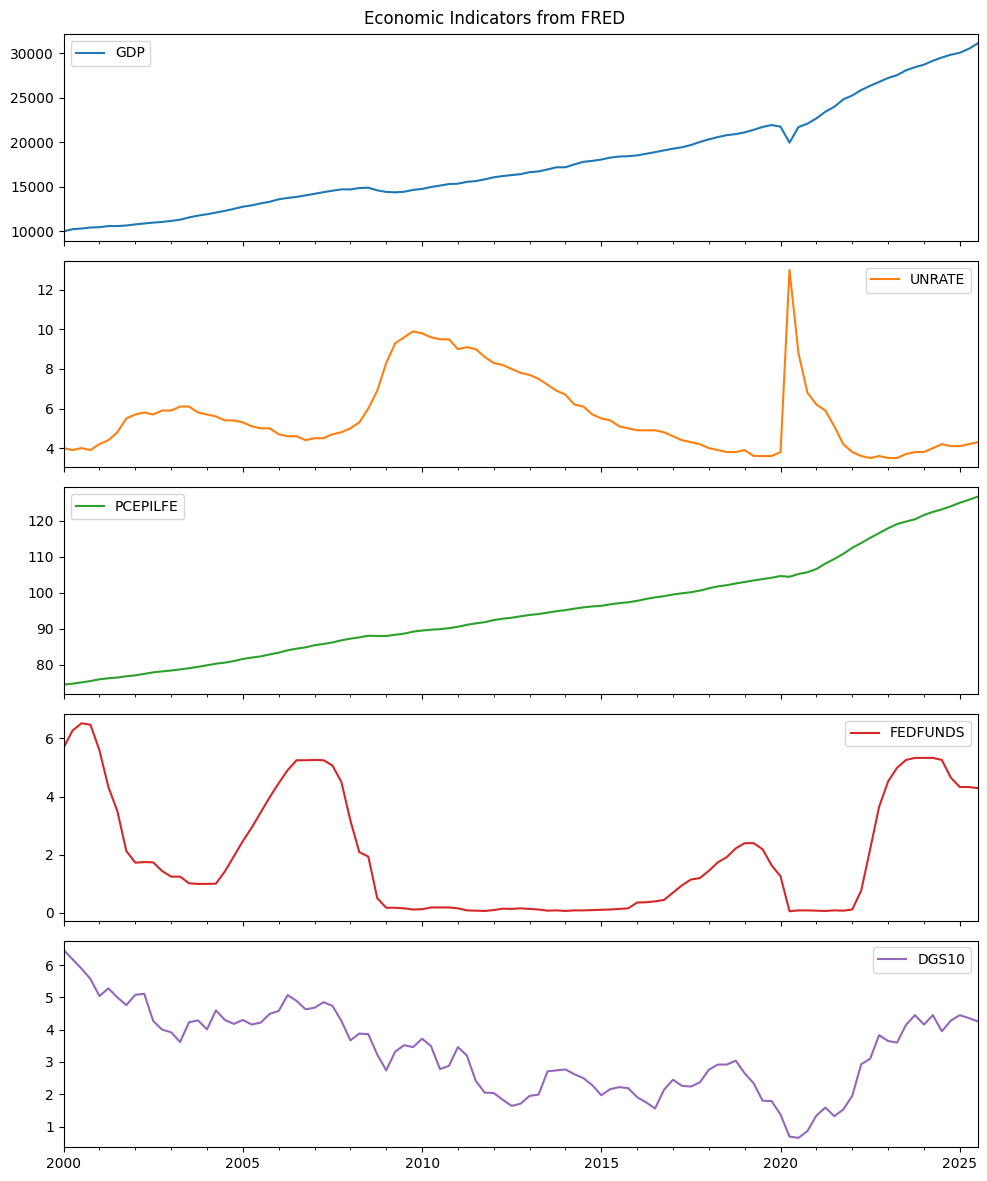

In [ ]:
df.plot(subplots=True, figsize=(10, 12), title='Economic Indicators from FRED')
plt.tight_layout()

# OBSERVATION

* The 10-year constant maturity rate exhibits high volatility over time.

* GDP and PCE Personal Consumption Expenditures (PCEPILFE) show generally linear trends but both experienced sharp declines during the pandemic.

* The unemployment rate spiked significantly, coinciding with the pandemic period.

* Federal Funds Rate (FEDFUNDS) has shown a notable upward trend since its spike in 2005.

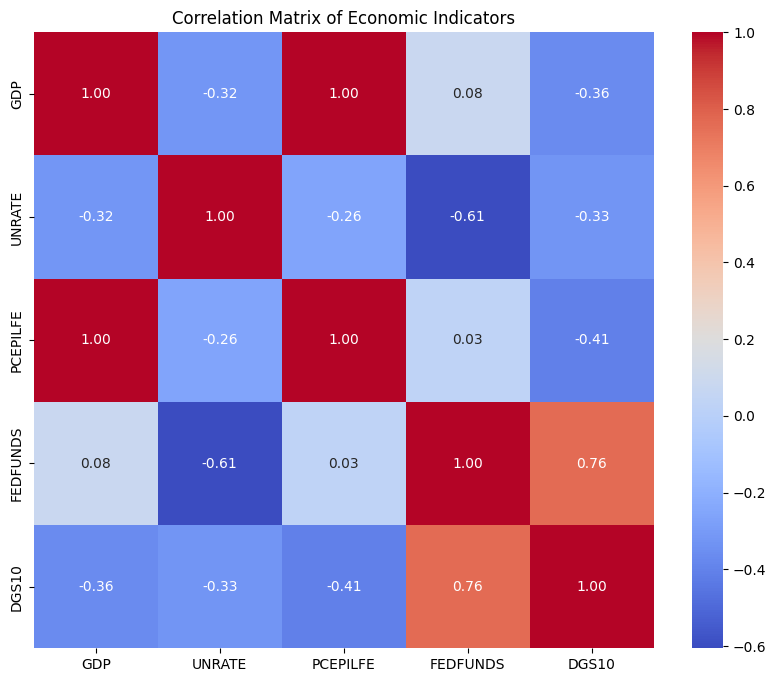

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)
plt.title('Correlation Matrix of Economic Indicators')
plt.show()

> OBSERVATION
>>* There is a strong correlation between the PCEPILFE and the Gross domestic product, indicating that when one increases, the other tends to increase as well. This suggests a close linear association between the two series.
>>* All others are weak

In [ ]:
df.describe()

,GDP,UNRATE,PCEPILFE,FEDFUNDS,DGS10
count,103.000000,103.000000,103.000000,103.000000,103.000000
mean,17766.345631,5.644660,94.983505,1.989223,3.315437
std,5646.486719,1.942796,13.936816,2.035308,1.290138
min,10002.179000,3.500000,74.430000,0.060000,0.650000
25%,13811.806000,4.200000,84.201000,0.145000,2.230000
50%,16420.419000,5.000000,93.435000,1.250000,3.460000
75%,21014.733500,6.200000,103.181500,3.815000,4.285000
max,31095.089000,13.000000,126.694000,6.520000,6.470000


<Axes: >

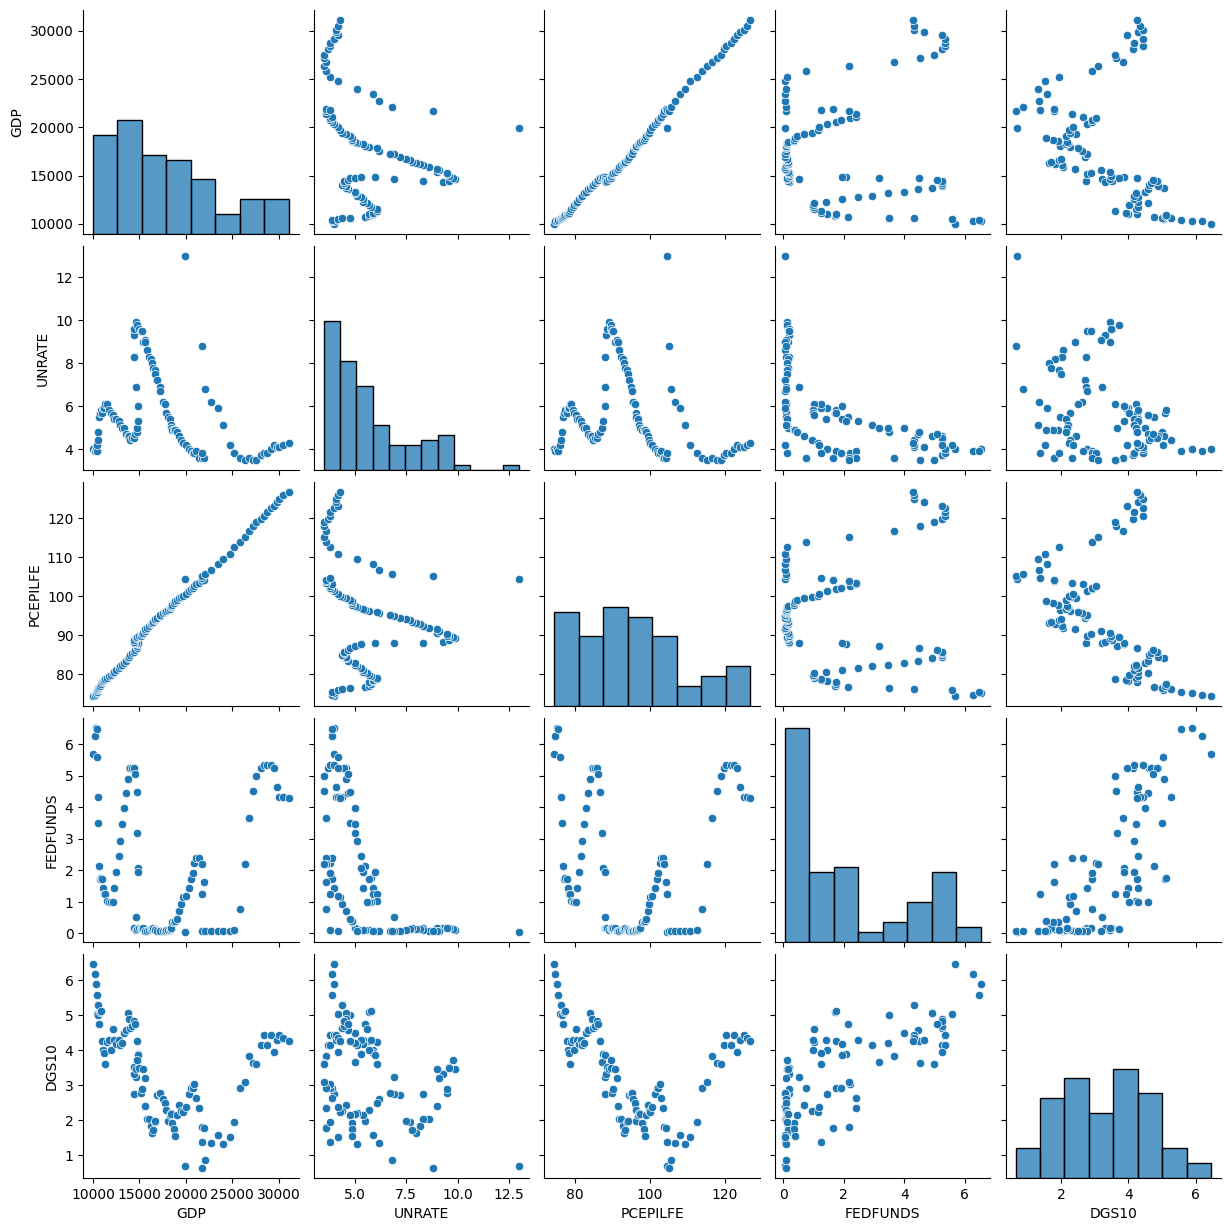

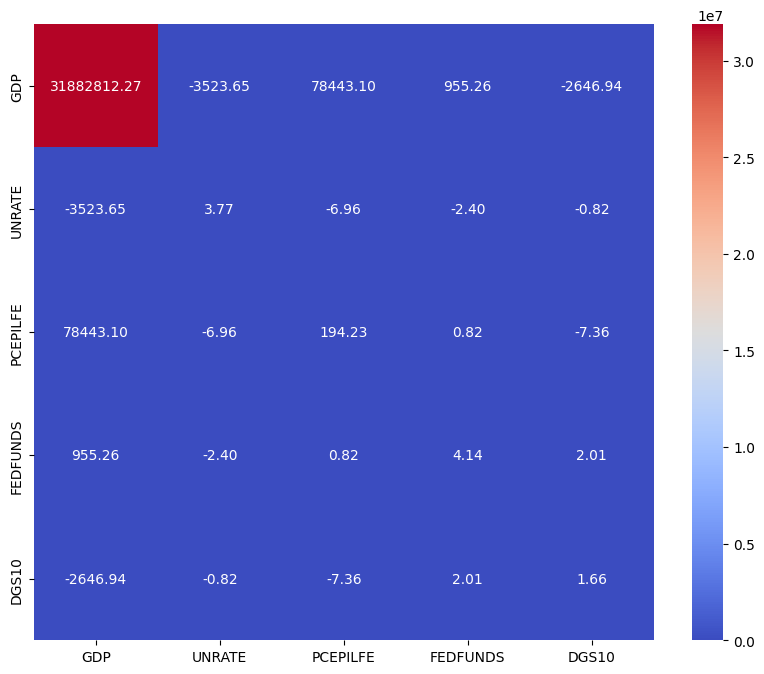

In [ ]:
sns.pairplot(df)
df.cov()
plt.figure(figsize=(10, 8))
sns.heatmap(
    df.cov(),
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

> OBSERVATION
>>* There is a strong directional relationship between the PCEPILFE and the Gross domestic product
>>> * In the Pairplot there was a linear relationship for both Macroeconomic instruments.
>>> * The covariance between GDP and PCEPIFE is positive, which means they generally move in the same direction. This directional co-movement supports the correlation result, though the exact magnitude depends on the scale of the data
>>* All others are weak

In [ ]:
df2= df[['GDP', 'PCEPILFE']]
df2.head()

,GDP,PCEPILFE
2000-01-01,10002.179,74.430
2000-04-01,10247.720,74.689
2000-07-01,10318.165,75.050
2000-10-01,10435.744,75.421
2001-01-01,10470.231,75.912


In [ ]:
from statsmodels.tsa.stattools import grangercausalitytests

In [ ]:
grangercausalitytests(df2, maxlag=5)


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=1.0203  , p=0.3149  , df_denom=99, df_num=1
ssr based chi2 test:   chi2=1.0513  , p=0.3052  , df=1
likelihood ratio test: chi2=1.0459  , p=0.3065  , df=1
parameter F test:         F=1.0203  , p=0.3149  , df_denom=99, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=3.3871  , p=0.0379  , df_denom=96, df_num=2
ssr based chi2 test:   chi2=7.1271  , p=0.0283  , df=2
likelihood ratio test: chi2=6.8869  , p=0.0320  , df=2
parameter F test:         F=3.3871  , p=0.0379  , df_denom=96, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=3.5308  , p=0.0179  , df_denom=93, df_num=3
ssr based chi2 test:   chi2=11.3898 , p=0.0098  , df=3
likelihood ratio test: chi2=10.7865 , p=0.0129  , df=3
parameter F test:         F=3.5308  , p=0.0179  , df_denom=93, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test:         F=2.5709  , p=0.0431  , df_d

{np.int64(1): ({'ssr_ftest': (np.float64(1.0203496766139801),
    np.float64(0.31489855887295537),
    np.float64(99.0),
    np.int64(1)),
   'ssr_chi2test': (np.float64(1.0512693637841006),
    np.float64(0.3052149220408421),
    np.int64(1)),
   'lrtest': (np.float64(1.0458888155321802),
    np.float64(0.3064558331759863),
    np.int64(1)),
   'params_ftest': (np.float64(1.0203496766140863),
    np.float64(0.3148985588729289),
    np.float64(99.0),
    1.0)},
   array([[0., 1., 0.]])]),
 np.int64(2): ({'ssr_ftest': (np.float64(3.3871379277697695),
    np.float64(0.0378936783936805),
    np.float64(96.0),
    np.int64(2)),
   'ssr_chi2test': (np.float64(7.127102723015556),
    np.float64(0.02833800729228434),
    np.int64(2)),
   'lrtest': (np.float64(6.886876432467943),
    np.float64(0.03195462931283543),
    np.int64(2)),
   'params_ftest': (np.float64(3.387137927769624),
    np.float64(0.03789367839368569),
    np.float64(96.0),
    2.0)},
   array([[0., 0., 1., 0., 0.],
         

# OBSERVATION

Based on the correlation and covariance analysis above, I decided to examine the causality between GDP and PCEPILFE separately before performing a general causal check. Since I am validating two variables, I employed Granger causality from the statsmodels library.

## Findings

The first lag shows no Granger causal effect on GDP. However, subsequent lags provide sufficient evidence to reject the null hypothesis. Specifically, information from lags 2 to 5 indicates that PCEPILFE has a Granger causal effect on GDP.



In [ ]:
from statsmodels.tsa.api import VAR

In [ ]:
VAR_model = VAR(df)
result = VAR_model.fit(maxlags=15, ic='aic')

In [ ]:
print("Selected lag order:", result.k_ar)

Selected lag order: 15


In [ ]:
print(result.test_causality('GDP', ['UNRATE', 'PCEPILFE', 'FEDFUNDS', 'DGS10'], kind='f'))

<statsmodels.tsa.vector_ar.hypothesis_test_results.CausalityTestResults object. H_0: ['UNRATE', 'PCEPILFE', 'FEDFUNDS', 'DGS10'] do not Granger-cause GDP: reject at 5% significance level. Test statistic: 2.236, critical value: 1.534>, p-value: 0.001>


# OBSERVATION

I wanted to examine how all variables interact simultaneously in predicting GDP. To achieve this, I employed Vector Autoregression (VAR), which helps assess the combined Granger causal effects of multiple variables on GDP. I initially considered a 15-lag reference, but to avoid overfitting, and noise, I used an information criterion to select the optimal lag length. Specifically, I applied the Akaike Information Criterion (AIC) to minimize residual errors while penalizing the inclusion of unnecessary parameters.

## findings

### What This Means Practically
- Past values of UNRATE, PCEPILFE, FEDFUNDS, and DGS10 contain predictive information about future GDP.
- In other words, GDP is not independent of these variables — they help explain its movements.
- This is consistent with macroeconomic theory: labor market conditions, inflation, monetary policy, and long-term interest rates all influence GDP growth

**VAR causality test shows strong evidence (p=0.001) that the combination of unemployment, inflation, policy rate, and bond yields Granger-cause GDP**




In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# What Does the Standard Scaler Do

* The **Standard Scaler** normalizes data by transforming it to have a **mean of 0** and a **standard deviation of 1**.
* This ensures that all features are on a comparable scale, **reducing the influence of outliers** and improving model performance.

### Formula

X - X(mean)/standard deviation (X)

In [ ]:
x= df.drop('GDP', axis=1)
y= df['GDP']

We separate **X** from **y**, i.e., we separate the **independent variable** (**GDP**) from the **dependent variables** (`UNRATE`, `PCEPILFE`, `FEDFUNDS`, `DGS10`).


In [ ]:
x

,UNRATE,PCEPILFE,FEDFUNDS,DGS10
2000-01-01,4.0,74.430,5.68,6.47
2000-04-01,3.9,74.689,6.27,6.18
2000-07-01,4.0,75.050,6.52,5.89
2000-10-01,3.9,75.421,6.47,5.57
2001-01-01,4.2,75.912,5.59,5.04
...,...,...,...,...
2024-07-01,4.2,123.168,5.26,3.95
2024-10-01,4.1,123.997,4.65,4.28
2025-01-01,4.1,125.000,4.33,4.45
2025-04-01,4.2,125.804,4.33,4.36


In [ ]:
y

,GDP
2000-01-01,10002.179
2000-04-01,10247.720
2000-07-01,10318.165
2000-10-01,10435.744
2001-01-01,10470.231
...,...
2024-07-01,29511.664
2024-10-01,29825.182
2025-01-01,30042.113
2025-04-01,30485.729


In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled= scaler.transform(x_test)


We import **train_test_split** to properly divide the data into **training** and **testing** sets. After the split, we **fit and transform** `X_train` and **transform** `X_test` using a scaler.  

> **Note:**  
> Scaling must be done **after splitting the data** to avoid overfitting. If the scaler is fit on the entire dataset, the model would be indirectly exposed to the test data, making predictions less meaningful because it has already "seen" the true values.


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

* **Model for Prediction:** Linear Regression  
* **Accuracy Metrics:** Mean Squared Error (MSE), R² Score


In [ ]:
model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(x_test)

In [ ]:
y_pred

array([14558.13671523, 19391.65190258, 18561.69754784, 15846.34900178,
       14985.37683941, 14871.2842991 , 26223.68497448, 15574.55357874,
       10961.04823788, 10143.5691352 , 12095.50314188, 14727.27585256,
       29214.52903125, 22785.95838176, 21197.16488667, 10569.02803724,
       21628.7097436 , 14902.13432742, 11095.28688735, 13899.53793848,
       30203.58885332])

In [ ]:
mean_squared_error(y_test, y_pred)

37565.20710041349

**Mean Squared Error (MSE):**  
MSE measures the average squared difference between the predicted and actual values. A lower value indicates better model performance.  

In this case, the MSE is **37,565.21**, which indicates a reasonably good fit for the model.


In [ ]:
r2_score(y_test, y_pred)

0.9988930782810531

**R² Score:**  
The R² score indicates how well the model's predictions match the actual values. In this case, the model achieves **99.8% accuracy**, demonstrating an excellent fit.


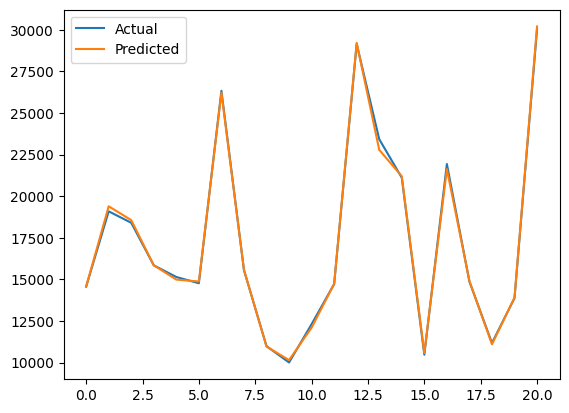

In [ ]:

plt.plot(y_test.values, label="Actual")
plt.plot(y_pred, label="Predicted")
plt.legend()
plt.show()


**Prediction Plot:**  
The plot illustrates the model's prediction accuracy. The **yellow line** represents the model's predicted values, while the **blue line** shows the actual recorded values. The close alignment of the two lines indicates high prediction accuracy.


In [ ]:
x_next = x.iloc[-1:].copy()
gdp_next = model.predict(x_next)
print(f"Predicted next GDP: {gdp_next[0]:,.2f}")


Predicted next GDP: 30,831.60


**Next GDP Prediction:**  
This shows the predicted GDP for the upcoming quarter. The prediction is based on the most recent **X** data fed into the model.


**Advice:**  
Practice consistently with this model to become more familiar with its workings and to strengthen your machine learning skills.
